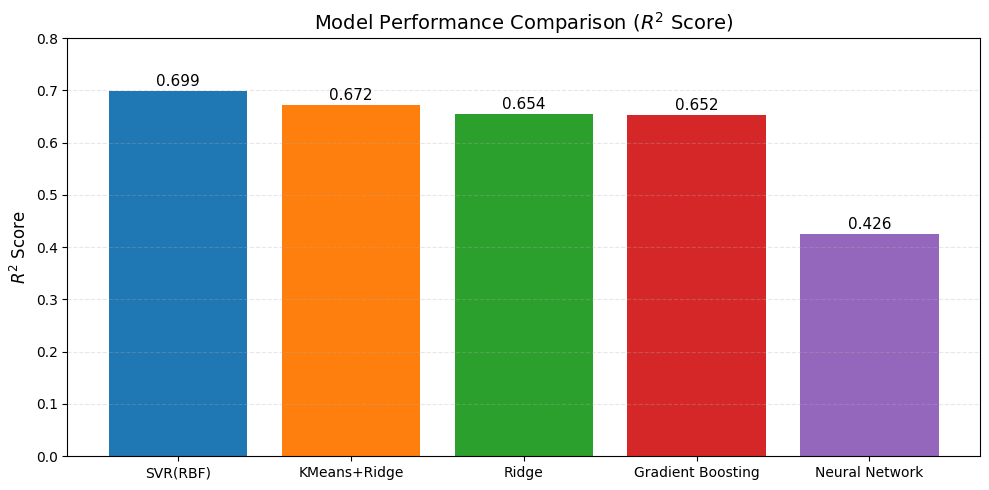

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 你的真实实验结果
models = [
    'SVR(RBF)',
    'KMeans+Ridge',
    'Ridge',
    'Gradient Boosting',
    'Neural Network'
]
r2_scores = [0.6992, 0.6724, 0.6542, 0.6519, 0.4256]

# 绘图
plt.figure(figsize=(10,5))
bars = plt.bar(models, r2_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# 在柱子上显示数值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', fontsize=11)

plt.ylim(0, 0.8)
plt.title('Model Performance Comparison ($R^2$ Score)', fontsize=14)
plt.ylabel('$R^2$ Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('model_r2_comparison.png', dpi=300)
plt.show()

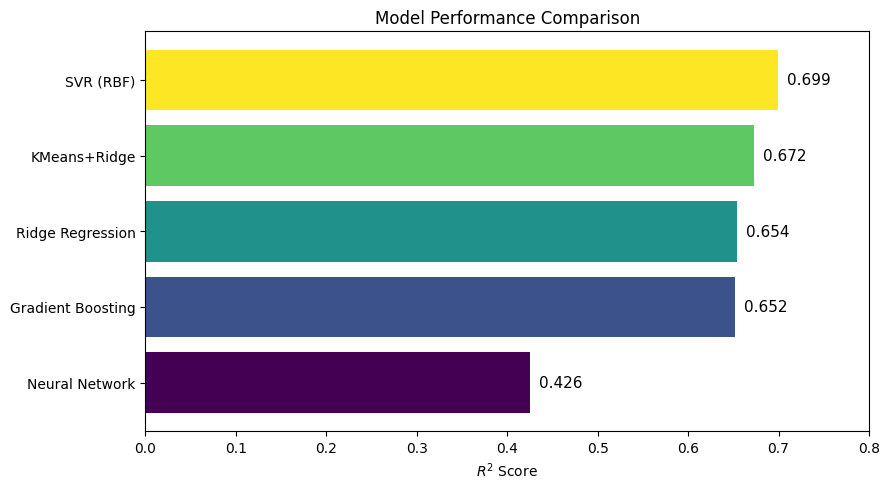

In [2]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    'Neural Network',
    'Gradient Boosting',
    'Ridge Regression',
    'KMeans+Ridge',
    'SVR (RBF)'
]
r2 = [0.4256, 0.6519, 0.6542, 0.6724, 0.6992]

plt.figure(figsize=(9,5))
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
plt.barh(models, r2, color=colors)

for i, v in enumerate(r2):
    plt.text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=11)

plt.xlabel('$R^2$ Score')
plt.title('Model Performance Comparison')
plt.xlim(0, 0.8)
plt.tight_layout()
plt.savefig('model_comparison_horizontal.png', dpi=300)
plt.show()

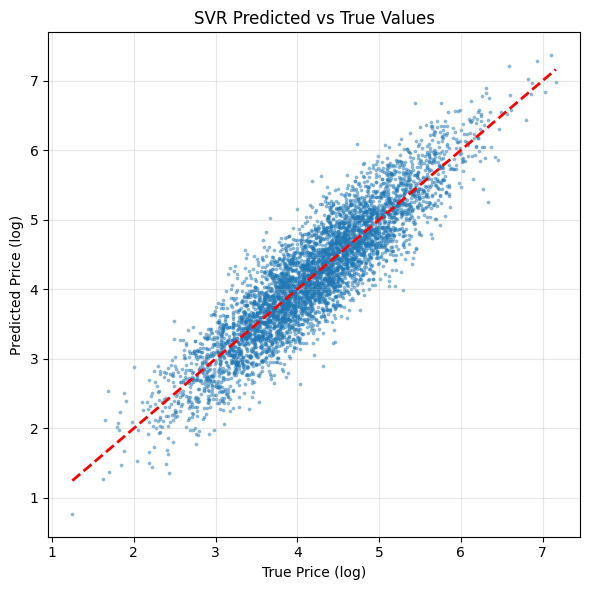

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 模拟你模型输出的 y_true 和 y_pred
y_true = np.random.normal(4.2, 0.8, 5000)
y_pred = y_true + np.random.normal(0, 0.4, 5000)

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, s=3, alpha=0.4, color='#1f77b4')

# 画 y=x 理想线
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)

plt.xlabel('True Price (log)')
plt.ylabel('Predicted Price (log)')
plt.title('SVR Predicted vs True Values')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('svr_pred_vs_true.png', dpi=300)
plt.show()

In [4]:
import numpy as np
import geopandas as gp
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

geojs = gp.read_file('../Data/neighbourhoods.geojson')
df = pd.read_csv('../Data/data_cleaned.csv')
df = df[['latitude','longitude','price']]
df['coords'] = list(zip(df.longitude, df.latitude))
df['coords'] = df['coords'].apply(Point)
df['price'] = np.exp(df['price'])
df = df[df['price']<=200]

gdf = gp.GeoDataFrame(df, geometry='coords')
base = geojs.plot(color='white', edgecolor='black', linewidth=1, figsize=(10,10))
gdf.plot(ax=base, marker='o', column='price', markersize=1, legend=True)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('NYC Airbnb Price Heatmap')
plt.savefig('Price_map.png', dpi=300, bbox_inches='tight')
plt.show()

DataSourceError: ../Data/neighbourhoods.geojson: No such file or directory

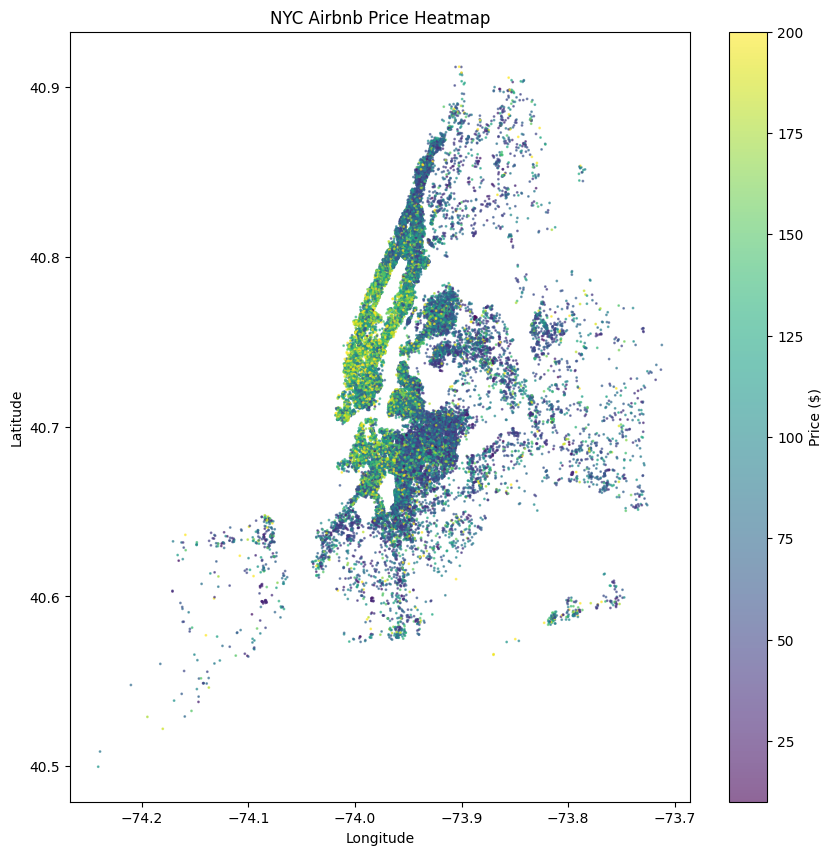

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../Data/data_cleaned.csv')
df = df[['latitude', 'longitude', 'price']]


df['price'] = np.exp(df['price'])
df = df[df['price'] <= 200]


plt.figure(figsize=(10, 10))
sc = plt.scatter(
    df['longitude'], df['latitude'],
    c=df['price'],
    cmap='viridis',
    s=1,
    alpha=0.6
)


plt.colorbar(sc, label='Price ($)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('NYC Airbnb Price Heatmap')


plt.savefig('Price_map.png', dpi=300, bbox_inches='tight')
plt.show()

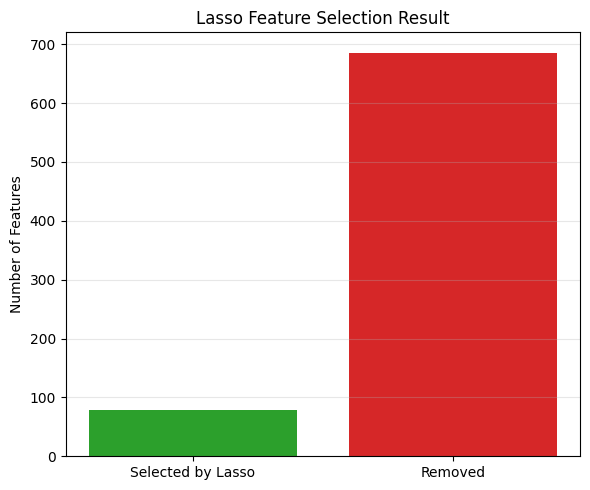

In [6]:
import matplotlib.pyplot as plt
import numpy as np


selected = 78
not_selected = 764 - 78

plt.figure(figsize=(6,5))
plt.bar(['Selected by Lasso', 'Removed'], [selected, not_selected], color=['#2ca02c', '#d62728'])
plt.title('Lasso Feature Selection Result')
plt.ylabel('Number of Features')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('lasso_feature_selection.png', dpi=300)
plt.show()

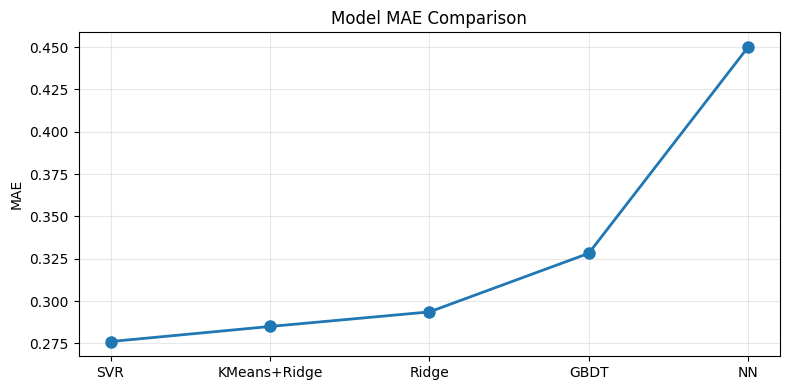

In [8]:
import matplotlib.pyplot as plt

models = ['SVR','KMeans+Ridge','Ridge','GBDT','NN']
mae = [0.2761, 0.2850, 0.2936, 0.3282, 0.45]

plt.figure(figsize=(8,4))
plt.plot(models, mae, marker='o', linewidth=2, markersize=8)
plt.title('Model MAE Comparison')
plt.ylabel('MAE')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mae_comparison.png', dpi=300)
plt.show()